In [ ]:
import os

os.chdir("/data/leuven/365/vsc36564/physioex/")

VSC_DATA = os.environ["VSC_DATA"]
DATA_FOLDER = os.path.join(
    os.environ["VSC_SCRATCH_PROJECTS_BASE"], "2024_111", "guido", "sleep-data"
)

import sys

sys.path.append(os.path.join(VSC_DATA, "physioex", "articles", "ProtoEx-Sleep", "src"))

import numpy as np
import pandas as pd
import pytorch_lightning as pl
import torch
from group_classification import GroupModule
from staging_util import GroupDataset
from tqdm import tqdm

from physioex.data import PhysioExDataModule
from physioex.train.models import load_model

pl.seed_everything(42)

# GROUP = "alzheimers"

GROUP = "parkinsons"

num_folds = 4

encoder_name = "protosleeptransformer"
encoder_class = "physioex.train.networks.protosleeptransformer:ProtoSleepTransformerNet"

# encoder_name = "protoseqsleepnet"
# encoder_class = "physioex.train.networks.protoseqsleepnet:ProtoSeqSleepNet"

[rank: 0] Seed set to 42


In [8]:
# plotting utils
%matplotlib inline
from matplotlib import pyplot as plt

try:
    plt.style.use("seaborn-v0_8-paper")
except:
    print("Error: one of the styles is not available")
    print(plt.style.available)
    exit(1)

tex_fonts = {
    # Use LaTeX to write all text
    # "text.usetex": True,
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(tex_fonts)

# column paper size 252.0pt
# use golden ratio for height

width = 252.0 / 72.0  # convert from points to inches
height = width

figsize = (width, height)


## Compute cross-fold (4) performances of the models for both nights-subjects levels


In [9]:
# sklearn metrics for binary Heatlhy vs Unhealthy classification
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

In [10]:
gd = GroupDataset(
    datasets=[GROUP],
    data_folder=DATA_FOLDER,
    preprocessing="xsleepnet",
    selected_channels=["EEG", "EOG", "EMG"],
    sequence_length=21,
)

gd.set_num_folds(num_folds)

model_kwargs = {"in_channels": 3, "sequence_length": 21}

results = []
preds = []

for FOLD in range(num_folds):
    print(f"Fold {FOLD + 1} of {num_folds}")
    if FOLD >= 8:
        break

    datamodule = PhysioExDataModule(
        datasets=gd,
        batch_size=1,
        folds=FOLD,
        num_workers=18,
        data_prefetch=False,
    )

    ckpt_path = f"articles/ProtoEx-Sleep/models/debug/{encoder_name}/group/{GROUP}/staging/fold={FOLD}/"
    # list files inside
    files = [f for f in os.listdir(ckpt_path) if f.endswith(".ckpt")][0]
    ckpt_path = os.path.join(ckpt_path, files)

    encoder = load_model(
        model=encoder_class,
        model_kwargs=model_kwargs,
        ckpt_path=ckpt_path,
        softmax=False,
        summary=False,
    ).eval()

    ckpt_path = f"articles/ProtoEx-Sleep/models/debug/{encoder_name}/group/{GROUP}/groups/fold={FOLD}/"
    # list files inside
    files = [f for f in os.listdir(ckpt_path) if f.endswith(".ckpt")][0]
    ckpt_path = os.path.join(ckpt_path, files)

    model = GroupModule.load_from_checkpoint(
        ckpt_path,
        encoder=encoder,
        input_size=128,  # Assuming the input feature size is 128
        hidden_size=64,  # Size of the hidden state
        num_layers=4,  # Number of LSTM layers
        attention_size=32,  # Size of the attention layer
        class_weights=gd.group_weights(),
    ).eval()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    with torch.no_grad():
        subjects_preds, subjects_proto_preds, subjects_labels = [], [], []

        for batch in tqdm(datamodule.test_dataloader()):
            x, _, y, _ = batch
            night_length = x.shape[1]

            y_hat, y_hat_proto = model.eval_on_night(x.to(device))
            y_hat = torch.nn.functional.softmax(y_hat.reshape(-1, 2).sum(dim=0), dim=-1)
            y_hat_proto = torch.nn.functional.softmax(
                y_hat_proto.reshape(-1, 2).sum(dim=0), dim=-1
            )
            subjects_preds.append(y_hat.reshape(-1, 2).detach().cpu().numpy())
            subjects_labels.append(y.reshape(-1).detach().cpu().numpy())
            subjects_proto_preds.append(
                y_hat_proto.reshape(-1, 2).detach().cpu().numpy()
            )

    model = model.cpu()

    subjects_preds = np.concatenate(subjects_preds, axis=0)
    subjects_labels = np.concatenate(subjects_labels, axis=0)
    subjects_proto_preds = np.concatenate(subjects_proto_preds, axis=0)

    res = {}
    res["fold"] = FOLD

    res["subjects_acc"] = accuracy_score(
        subjects_labels, np.argmax(subjects_preds, axis=1)
    )
    res["subjects_f1"] = f1_score(
        subjects_labels, np.argmax(subjects_preds, axis=1), average="weighted"
    )
    res["subjects_precision"] = precision_score(
        subjects_labels, np.argmax(subjects_preds, axis=1), average="weighted"
    )
    res["subjects_recall"] = recall_score(
        subjects_labels, np.argmax(subjects_preds, axis=1), average="weighted"
    )

    res["subjects_proto_acc"] = accuracy_score(
        subjects_labels, np.argmax(subjects_proto_preds, axis=1)
    )
    res["subjects_proto_f1"] = f1_score(
        subjects_labels, np.argmax(subjects_proto_preds, axis=1), average="weighted"
    )
    res["subjects_proto_precision"] = precision_score(
        subjects_labels, np.argmax(subjects_proto_preds, axis=1), average="weighted"
    )
    res["subjects_proto_recall"] = recall_score(
        subjects_labels, np.argmax(subjects_proto_preds, axis=1), average="weighted"
    )

    preds.append(
        {
            "fold": FOLD,
            "subjects_preds": subjects_preds,
            "subjects_labels": subjects_labels,
            "subjects_proto_preds": subjects_proto_preds,
        }
    )

    results.append(res)

# convert the results to a DataFrame
results_df = pd.DataFrame(results)
results_df.to_csv(
    f"articles/ProtoEx-Sleep/models/debug/{encoder_name}/group/{GROUP}/groups/results.csv",
    index=False,
)
results_df.mean()


2025-08-08 12:51:00.400 | WARNING  | physioex.data.datareader:__init__:64 - Sequence length 86400 is greater than the max number of windows 1338 for dataset parkinsons/night/HOA.
Loading healthy dataset:   0%|          | 0/40 [00:00<?, ?it/s]

Loading healthy dataset: 100%|██████████| 40/40 [00:15<00:00,  2.66it/s]
2025-08-08 12:51:15.500 | WARNING  | physioex.data.datareader:__init__:64 - Sequence length 86400 is greater than the max number of windows 1452 for dataset parkinsons/night/PD.
Loading unhealthy dataset: 100%|██████████| 46/46 [00:17<00:00,  2.65it/s]
2025-08-08 12:51:32.860 | WARNING  | physioex.data.datamodule:__init__:93 - The usage of PhysioExDataset as datasets is deprecated. Please use a list of dataset names instead.


Fold 1 of 4


Splitting test set into sequences: 100%|██████████| 22/22 [00:00<00:00, 141.35it/s]


Dataset split into 52519 train, 13 valid, and 22 test sequences.


...

Fold 4 of 4


Splitting test set into sequences: 100%|██████████| 21/21 [00:00<00:00, 171.97it/s]
/readonly/dodrio/apps/RHEL8/zen2-ampere-ib/software/PyTorch-Lightning/2.2.1-foss-2023a-CUDA-12.1.1/lib/python3.11/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


Dataset split into 54691 train, 13 valid, and 21 test sequences.


/readonly/dodrio/apps/RHEL8/zen2-ampere-ib/software/PyTorch/2.1.2-foss-2023a-CUDA-12.1.1/lib/python3.11/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
100%|██████████| 21/21 [00:11<00:00,  1.90it/s]
/readonly/dodrio/apps/RHEL8/zen2-ib/software/scikit-learn/1.4.2-gfbf-2023a/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


fold                        1.500000
subjects_acc                0.534632
subjects_f1                 0.485198
subjects_precision          0.475298
subjects_recall             0.534632
subjects_proto_acc          0.407468
subjects_proto_f1           0.294732
subjects_proto_precision    0.238050
subjects_proto_recall       0.407468
dtype: float64

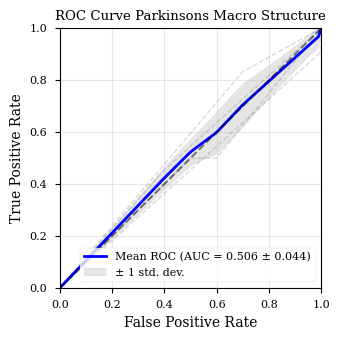

In [11]:
# plot the ROC curve for both nights and subjects for all the folds ( all the folds curves in the same plot )
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_curve

# update the code to make a single plot for both nights and subjects ( subplot 1 row  2 columns )
fig, axs = plt.subplots(1, 1, figsize=figsize, sharex=True, sharey=True)

# Common FPR grid for interpolation
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

# Plot individual fold curves with same color and dashed lines
for i, fold_data in enumerate(preds):
    subjects_preds = fold_data["subjects_preds"]
    subjects_labels = fold_data["subjects_labels"]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(subjects_labels, subjects_preds[:, 1])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # Interpolate TPR values at common FPR points
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    # Plot individual curves
    axs.plot(fpr, tpr, color="gray", alpha=0.3, linestyle="--", linewidth=1)

# Calculate mean and std
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

# Plot mean curve
axs.plot(
    mean_fpr,
    mean_tpr,
    color="blue",
    linewidth=2,
    label=f"Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})",
)

# Plot confidence interval
axs.fill_between(
    mean_fpr, tprs_lower, tprs_upper, color="gray", alpha=0.2, label="± 1 std. dev."
)

# Plot diagonal line
axs.plot([0, 1], [0, 1], "k--", alpha=0.5)

axs.set_title(f"ROC Curve {GROUP.capitalize()} Macro Structure")
axs.legend(loc="lower right")
axs.set_xlabel("False Positive Rate")
axs.set_ylabel("True Positive Rate")
axs.set_xlim([0.0, 1.0])
axs.set_ylim([0.0, 1.0])

axs.grid(True, alpha=0.3)

plt.tight_layout()

filename = f"{GROUP}-{encoder_name}-macro-roc-curves"

fig.savefig(
    f"articles/ProtoEx-Sleep/models/debug/{encoder_name}/group/{GROUP}/groups/{filename}.pdf",
    format="pdf",
    bbox_inches="tight",
)

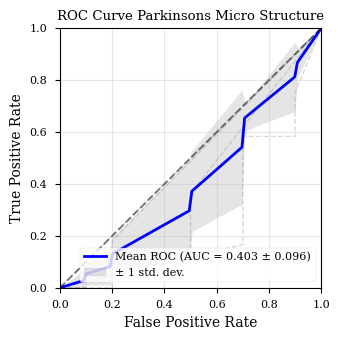

In [12]:
# update the code to make a single plot for both nights and subjects ( subplot 1 row  2 columns )
fig, axs = plt.subplots(1, 1, figsize=figsize, sharex=True, sharey=True)

# Common FPR grid for interpolation
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

# Plot individual fold curves with same color and dashed lines
for i, fold_data in enumerate(preds):
    subjects_preds = fold_data["subjects_proto_preds"]
    subjects_labels = fold_data["subjects_labels"]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(subjects_labels, subjects_preds[:, 1])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # Interpolate TPR values at common FPR points
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    # Plot individual curves
    axs.plot(fpr, tpr, color="gray", alpha=0.3, linestyle="--", linewidth=1)

# Calculate mean and std
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

# Plot mean curve
axs.plot(
    mean_fpr,
    mean_tpr,
    color="blue",
    linewidth=2,
    label=f"Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})",
)

# Plot confidence interval
axs.fill_between(
    mean_fpr, tprs_lower, tprs_upper, color="gray", alpha=0.2, label="± 1 std. dev."
)

# Plot diagonal line
axs.plot([0, 1], [0, 1], "k--", alpha=0.5)

axs.set_title(f"ROC Curve {GROUP.capitalize()} Micro Structure")
axs.legend(loc="lower right")
axs.set_xlabel("False Positive Rate")
axs.set_ylabel("True Positive Rate")
axs.set_xlim([0.0, 1.0])
axs.set_ylim([0.0, 1.0])

axs.grid(True, alpha=0.3)

plt.tight_layout()

filename = f"{GROUP}-{encoder_name}-micro-roc-curves"

fig.savefig(
    f"articles/ProtoEx-Sleep/models/debug/{encoder_name}/group/{GROUP}/groups/{filename}.pdf",
    format="pdf",
    bbox_inches="tight",
)